# Stats 292 — Statistical Models of Text and Language
## Homework: Frequency Statistics on Bluesky Skeets

> **Course:** Stats 292, Prof. David Donoho, Spring 2026  
> **Based on:** Manning & Schütze, *Foundations of Statistical Natural Language Processing*, Chapters 1, 2, 5, 6; Jurafsky & Martin, *Speech and Language Processing*, Chapter 3.  
> **Data source:** BSky2GBQ — Bluesky firehose archive in Google BigQuery (`` `stanford-f24-datasci-194d.EMS.bsky-firehose` ``)

---

## Overview

This homework asks you to replicate and extend the core frequency-statistics analyses from the lectures using English-language Bluesky skeets as corpus. You will:

1. Build a **frequency-of-frequency table** (N_r) for two random equal-size subsamples, then apply **Good-Turing smoothing**.
2. Verify **Zipf's Law** and fit the **Mandelbrot formula** on cross-year word frequency data (2024 vs. 2025).
3. Compute a **bigram frequency table** and apply three collocation significance tests: **t-test**, **chi-squared**, and **Dunning's likelihood ratio**.
4. Attach **part-of-speech labels** to filter bigrams by Justeson & Katz patterns, and run a **near-synonym comparison** (Table 5.4 style).
5. Build unigram and bigram language models and compare their **log-perplexity** on held-out data.

## About the Data

[Bluesky](https://bsky.app) is a decentralized social network built on the AT Protocol. Since late October 2024, the Stanford BSky2GBQ project has continuously captured every public post ("skeet") from the Bluesky firehose and archived it in Google BigQuery. As of early 2026 the archive exceeds 2 billion posts spanning dozens of languages. For this homework you will query a reproducible 1% pseudo-random sample of English-language skeets from one week in November 2024 — roughly 300,000 posts. Bluesky text is short-form, informal, and multilingual, which makes it a rich test bed for the frequency-statistics methods covered in lecture: vocabulary distributions are heavy-tailed, collocations reflect contemporary slang and news events, and the sheer volume lets you observe smoothing and estimation effects that would be invisible in a small curated corpus.

---

## Environment Setup

All work for this course uses the `stats292` Conda environment. Create it once from the repo root:

```bash
conda env create -f environment.yml
conda activate stats292
```

Download the required NLTK data (also one-time):

```bash
python -c "import nltk; nltk.download('punkt_tab'); nltk.download('averaged_perceptron_tagger_eng')"
```

Authenticate with Google Cloud (one-time per machine, or when credentials expire). The `gcloud` CLI is included in the Conda environment, so no separate installation is needed:

```bash
gcloud auth application-default login
```

This opens a browser window; sign in with your Stanford Google account. The credentials are stored at `~/.config/gcloud/application_default_credentials.json` and are picked up automatically by the BigQuery client.

Register the environment as a Jupyter kernel so it appears in JupyterLab:

```bash
python -m ipykernel install --user --name stats292 --display-name "Python (stats292)"
```

If the environment already exists and needs updating after a package is added:

```bash
conda env update -f environment.yml --prune
```

**Before running any cells:** select Kernel → Change Kernel → Python (stats292).

---

## Setup: Fetching the Corpus

Fetch a reproducible pseudo-random 1% draw of English skeets using `FARM_FINGERPRINT` on the `sequence` column (avoids expensive `ORDER BY RAND()`):

In [1]:
from google.cloud import bigquery
import pandas as pd

client = bigquery.Client(project="stanford-f24-datasci-194d")

QUERY_SAMPLE = """
SELECT text
FROM `stanford-f24-datasci-194d.EMS.bsky-firehose`
WHERE JSON_VALUE(post_json, '$.record.langs[0]') = 'en'
  AND DATE(timestamp) BETWEEN '2024-11-18' AND '2024-11-24'
  AND MOD(ABS(FARM_FINGERPRINT(CAST(sequence AS STRING))), 100) < 1
"""

df_sample = client.query(QUERY_SAMPLE).to_dataframe()
print(f"Rows fetched: {len(df_sample):,}")

/Users/donoho/anaconda3/envs/stats292/lib/python3.11/site-packages/google/auth/_default.py:114: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


Rows fetched: 283,915


Tokenize all rows into a flat token list:

In [4]:
df_sample.head()

,text
0,I wish the dementia would really kick in now
1,No
2,"haven't gotten to god grove yet, is it any good?"
3,#TeamOxfordComma
4,And do you struggle with that?


In [2]:
import re

def tokenize(text):
    """Lowercase alphabetic tokenization; strips URLs, mentions, hashtags."""
    text = re.sub(r'https?://\S+|@\w+|#\w+', ' ', text)
    return re.findall(r'[a-z]+', text.lower())

tokens = []
for text in df_sample['text'].dropna():
    tokens.extend(tokenize(text))

print(f"Total tokens N = {len(tokens):,}")

Total tokens N = 4,205,516


---

## Part 1 — Frequency-of-Frequency Table and Good-Turing Smoothing

### Notation (from Table 6.2, Manning & Schütze)

| Symbol | Meaning |
|---|---|
| N | Number of training tokens |
| B | Vocabulary size |
| V | Number of n-gram types seen |
| C(w₁…wₙ) | Frequency of n-gram in training text |
| r | Frequency of an n-gram |
| N_r | Number of n-gram **types** with frequency exactly r |
| T_r | Total count in held-out data of all n-grams with training frequency r |

### 1a. Build Two Equal-Size Subsamples

Split the token list at the midpoint so both halves have the same number of tokens. Call Sample A the training set and Sample B the held-out set.

In [5]:
from collections import Counter

midpoint = len(tokens) // 2
tokens_a = tokens[:midpoint]   # "training" half
tokens_b = tokens[midpoint:]   # "held-out" half

freq_a = Counter(tokens_a)
freq_b = Counter(tokens_b)
vocab_all = set(freq_a) | set(freq_b)

N = len(tokens_a)
B = len(vocab_all)

print(f"Tokens per sample N = {N:,}")
print(f"Vocabulary |V∪| = {B:,}")
print(f"Types only in A: {len(set(freq_a) - set(freq_b)):,}")
print(f"Types only in B: {len(set(freq_b) - set(freq_a)):,}")

Tokens per sample N = 2,102,758
Vocabulary |V∪| = 125,523
Types only in A: 41,176
Types only in B: 41,580


### 1b. Compute N_r and T_r

For each r, N_r is the number of word types in the training half with exactly r occurrences. T_r is the total number of times those same types appear in the held-out half — this is the key quantity for estimating r*.

In [ ]:
def indicator_leq_zero(x):
    return 1 if x <= 0 else 0

def compute_nr_tr(freq_train, freq_held, r_max=10):
    """
    For r = 0..r_max:
      N_r = number of types in vocab_all with training freq exactly r
      T_r = total held-out count of those same types
    """
    rows = []
    for r in range(r_max + 1):
        types_at_r = [w for w in vocab_all if freq_train.get(w, 0) == r]
        nr = len(types_at_r)
        tr = sum(freq_held.get(w, 0) for w in types_at_r)
        rows.append({"r": r, "N_r": nr, "T_r": tr})

    types_nz = [w for w in vocab_all if freq_train.get(w, 0) > 0]
    nz = len(types_nz)
    tz = sum(indicator_leq_zero(freq_held.get(w, 0)) for w in types_nz)
    print(f"nz ={nz}; tz={tz}")
    return pd.DataFrame(rows)

table = compute_nr_tr(freq_a, freq_b, r_max=10)
print(table.to_string(index=False))


nr =83943; tr=41176
 r   N_r   T_r
 0 41580 49864
 1 46713 20077
 2 10520 15308
 3  5070 12172
 4  3177 10991
 5  2276 10186
 6  1675  9179
 7  1299  8444
 8  1026  7817
 9   874  7327
10   726  6913


### 1c. Good-Turing Adjusted Frequency

The Good-Turing theorem says the expected held-out count for n-grams seen r times in training is:

$$r^* = (r+1)\frac{E(N_{r+1})}{E(N_r)}$$

We estimate E(N_r) directly from our two-sample split: the average held-out frequency of n-grams with training frequency r is T_r / N_r. The Good-Turing adjusted frequency is then:

$$r^* \approx (r+1)\frac{N_{r+1}}{N_r}$$

The probability estimate for an unseen n-gram (r = 0) is:

$$P_{\text{GT}}(\text{unseen}) \approx \frac{N_1}{N_0 \cdot N}$$

In [7]:
table["r_star"] = (table["r"] + 1) * table["N_r"].shift(-1) / table["N_r"]
table["T_r_over_N_r"] = table["T_r"] / table["N_r"].replace(0, float('nan'))

print("=== Frequency-of-Frequency Table (Good-Turing) ===")
print(table[["r", "N_r", "T_r", "T_r_over_N_r", "r_star"]].to_string(index=False))

N1 = table.loc[table["r"] == 1, "N_r"].values[0]
N0 = table.loc[table["r"] == 0, "N_r"].values[0]
p_unseen = N1 / (N0 * N) if N0 > 0 else float('nan')
print(f"\nP_GT(unseen) ≈ N_1 / (N_0 · N) = {N1} / ({N0} · {N}) = {p_unseen:.2e}")
print(f"Total unobserved probability mass ≈ N_1 / N = {N1/N:.4f}")

=== Frequency-of-Frequency Table (Good-Turing) ===
 r   N_r   T_r  T_r_over_N_r   r_star
 0 41580 49864      1.199230 1.123449
 1 46713 20077      0.429795 0.450410
 2 10520 15308      1.455133 1.445817
 3  5070 12172      2.400789 2.506509
 4  3177 10991      3.459553 3.581996
 5  2276 10186      4.475395 4.415641
 6  1675  9179      5.480000 5.428657
 7  1299  8444      6.500385 6.318707
 8  1026  7817      7.618908 7.666667
 9   874  7327      8.383295 8.306636
10   726  6913      9.522039      NaN

P_GT(unseen) ≈ N_1 / (N_0 · N) = 46713 / (41580 · 2102758) = 5.34e-07
Total unobserved probability mass ≈ N_1 / N = 0.0222


**Expected table shape** (your numbers will differ):

| r | N_r | T_r | T_r / N_r | r* |
|---|---|---|---|---|
| 0 | ~15,000 | — | — | — |
| 1 | ~12,000 | ~6,000 | ~0.50 | ~1.0 |
| 2 | ~6,000 | ~8,000 | ~1.33 | ~1.5 |
| 3 | ~3,500 | ~7,000 | ~2.00 | ~2.0 |
| ... | ... | ... | ... | ... |

### 1d. Questions

**Question 1.1.** Unobserved probability mass. How many types appear in Sample A but have zero occurrences in Sample B? How did you come up with your answer? Did this require you to modify or adapt the above code? Expressed as a fraction of the combined vocabulary, what does this tell you about corpus coverage?

**Question 1.2.** Examine the column T_r / N_r for r = 1, 2, 3, … Does it increase approximately linearly with r? What does this imply about whether the MLE frequency r is a good estimate of the expected held-out frequency?

**Question 1.3.** Good and Turing used as an estimate of the total unobserved probability mass the ratio N_1/N. How does this compare with your answer to Question 1.1? Compare your value to the bigram result from Table 6.7 of Manning & Schütze (N_1 = 138,741 out of ~1.8M bigrams in the Austen corpus). What does a large N_1/N tell you about the sparsity of the skeet vocabulary?

**Question 1.4.** Using the Good-Turing formula, what is r* for r=1 (singletons)? Is it greater or less than 1? What does this mean for the estimated probability of a word you have seen exactly once?

*Your answers to Questions 1.1–1.4 here.*

---

## Part 2 — Zipf's Law and Cross-Year Word Frequency (2024 vs. 2025)

### 2a. Verify Zipf's Law

Zipf's law states f(w) · r(w) ≈ K for some constant K, where f is frequency and r is rank. Equivalently, log f ≈ log K − log r.

In [8]:
import math

# Use the training half (tokens_a) for unigram frequency
word_freq = freq_a.most_common()
ranks = range(1, len(word_freq) + 1)

zipf_rows = []
for rank, (word, freq) in enumerate(word_freq, start=1):
    zipf_rows.append({"rank": rank, "word": word, "freq": freq,
                      "freq_times_rank": freq * rank})

df_zipf = pd.DataFrame(zipf_rows)

print("=== Top 30 words: Zipf check ===")
print(df_zipf.head(30)[["rank", "word", "freq", "freq_times_rank"]].to_string(index=False))

=== Top 30 words: Zipf check ===
 rank word  freq  freq_times_rank
    1  the 68504            68504
    2    i 65154           130308
    3   to 50002           150006
    4    a 45231           180924
    5  and 38450           192250
    6   it 31753           190518
    7   of 30791           215537
    8  you 28550           228400
    9   is 25982           233838
   10    s 25544           255440
   11   in 23622           259842
   12 that 22531           270372
   13  for 20814           270582
   14 this 18418           257852
   15   my 17836           267540
   16   on 16097           257552
   17    t 15872           269824
   18   be 12679           228222
   19   so 12607           239533
   20  but 12347           246940
   21 with 12088           253848
   22 have 11433           251526
   23   me 11244           258612
   24  are 10834           260016
   25 they 10213           255325
   26  not 10123           263198
   27    m  9906           267462
   28  was  967

Plot log-rank vs. log-frequency (for the top 10,000 types):

Matplotlib is building the font cache; this may take a moment.


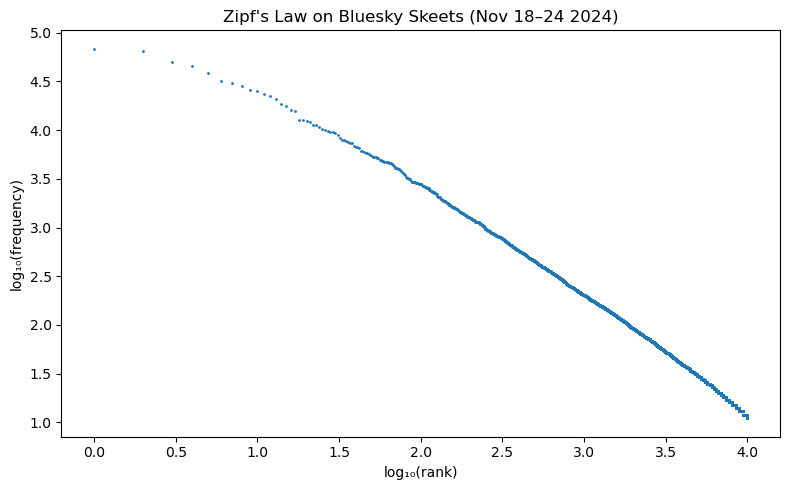

In [9]:
import matplotlib.pyplot as plt

top = df_zipf.head(10_000)
plt.figure(figsize=(8, 5))
plt.plot(top["rank"].apply(math.log10), top["freq"].apply(math.log10), '.', ms=2)
plt.xlabel("log₁₀(rank)")
plt.ylabel("log₁₀(frequency)")
plt.title("Zipf's Law on Bluesky Skeets (Nov 18–24 2024)")
plt.tight_layout()
plt.savefig("zipf_plot.png", dpi=150)
plt.show()

### 2b. Fit the Mandelbrot Formula

The Mandelbrot formula generalizes Zipf's law:

$$f(w) = P\,(r(w) + \rho)^{-B} \quad \Longleftrightarrow \quad \log f = \log P - B\cdot\log(r+\rho)$$

for constants P, B, ρ. Fit by OLS regression on the log-transformed data:

In [11]:
from scipy.stats import linregress
import numpy as np

rho = 10.0   # typical starting value; try tuning
log_f  = np.log10(df_zipf["freq"].values[:5000])
log_rr = np.log10(df_zipf["rank"].values[:5000] + rho)

slope, intercept, r_value, _, _ = linregress(log_rr, log_f)
B = -slope
log_P = intercept

print(f"Mandelbrot fit: B = {B:.3f}, log P = {log_P:.3f}, R² = {r_value**2:.4f}")
print(f"(Manning & Schütze Brown corpus: B ≈ 1.15, ρ ≈ 100)")

Mandelbrot fit: B = 1.181, log P = 5.858, R² = 0.9995
(Manning & Schütze Brown corpus: B ≈ 1.15, ρ ≈ 100)


### 2c. Cross-Year Frequency Table

Fetch a matching random sample from each year and compare relative frequencies:

In [12]:
def fetch_year_sample(year: int) -> pd.DataFrame:
    q = f"""
    SELECT text
    FROM `stanford-f24-datasci-194d.EMS.bsky-firehose`
    WHERE JSON_VALUE(post_json, '$.record.langs[0]') = 'en'
      AND DATE(timestamp) BETWEEN '{year}-11-18' AND '{year}-11-24'
      AND MOD(ABS(FARM_FINGERPRINT(CAST(sequence AS STRING))), 100) < 1
    """
    return client.query(q).to_dataframe()

df_2024 = fetch_year_sample(2024)
df_2025 = fetch_year_sample(2025)

def word_freq_from_df(df):
    counts = Counter()
    for text in df['text'].dropna():
        counts.update(tokenize(text))
    return counts

freq_2024 = word_freq_from_df(df_2024)
freq_2025 = word_freq_from_df(df_2025)

total_2024 = sum(freq_2024.values())
total_2025 = sum(freq_2025.values())

all_words = set(freq_2024) | set(freq_2025)
rows = []
for word in all_words:
    c24 = freq_2024.get(word, 0)
    c25 = freq_2025.get(word, 0)
    rpm_24 = c24 / total_2024 * 1_000_000
    rpm_25 = c25 / total_2025 * 1_000_000
    rows.append({"word": word, "count_2024": c24, "rpm_2024": rpm_24,
                 "count_2025": c25, "rpm_2025": rpm_25,
                 "rpm_ratio": (rpm_25 + 1e-6) / (rpm_24 + 1e-6)})

df_crossyear = pd.DataFrame(rows).sort_values("count_2024", ascending=False)

rising = df_crossyear[df_crossyear["count_2025"] >= 100].nlargest(20, "rpm_ratio")
print("=== Words rising most from 2024 → 2025 ===")
print(rising[["word", "count_2024", "count_2025", "rpm_ratio"]].to_string(index=False))

=== Words rising most from 2024 → 2025 ===
      word  count_2024  count_2025    rpm_ratio
   mamdani           0         481 1.988672e+08
       mbs           0         133 5.498822e+07
    zohran           0         108 4.465209e+07
cloudflare           2         127 1.104104e+02
     macro          18         732 7.070917e+01
     comey           3         107 6.201535e+01
     piggy          18         485 4.684966e+01
   epstein          57        1151 3.511056e+01
   impeach          10         103 1.790912e+01
     saudi          23         207 1.564875e+01
     files          98         822 1.458421e+01
  reporter          28         183 1.136398e+01
    orders          88         339 6.698141e+00
     bondi          58         208 6.235519e+00
 socialism          42         130 5.381847e+00
  substack         281         854 5.284317e+00
    regime          73         214 5.097159e+00
       pub         189         456 4.195081e+00
    miller          64         153 4.156700e+

### 2d. Questions

**Question 2.1.** Print the top 30 words with their rank, frequency, and f × r. Is the product approximately constant (Zipf's law)? Where does it deviate most — at the very top ranks (stop words) or the bottom (rare words)?

**Question 2.2.** Look at the log-log plot. Is the relationship linear throughout, or does it bend at the tails? How does your Mandelbrot B compare to the Brown corpus value of B ≈ 1.15?

**Question 2.3.** List 5 words that rose substantially from 2024 to 2025 in RPM. Can you hypothesize a real-world event for each?

**Question 2.4.** Does the vocabulary size (number of unique types) differ between 2024 and 2025 samples of the same size? What does this imply about Heaps' Law and corpus growth?

*Your answers to Questions 2.1–2.4 here.*

---

## Part 3 — Bigram Frequency and Collocation Significance Tests

### 3a. Compute Bigram Counts

In [13]:
from nltk.util import ngrams
import nltk
nltk.download('punkt', quiet=True)

bigram_counts = Counter(ngrams(tokens_a, 2))
total_bigrams = sum(bigram_counts.values())

top_bigrams = pd.DataFrame(
    bigram_counts.most_common(100),
    columns=["bigram", "count"]
)
top_bigrams[["w1", "w2"]] = pd.DataFrame(top_bigrams["bigram"].tolist(),
                                          index=top_bigrams.index)
top_bigrams = top_bigrams[["w1", "w2", "count"]]

print("=== Top 30 bigrams by raw count (cf. Table 5.1, Manning & Schütze) ===")
print(top_bigrams.head(30).to_string(index=False))

=== Top 30 bigrams by raw count (cf. Table 5.1, Manning & Schütze) ===
   w1     w2  count
    i      m   9150
   it      s   9003
  don      t   5242
   of    the   5228
   in    the   5121
 bsky social   3881
   to     be   3655
 this     is   3102
 that      s   3015
   on    the   2801
  and      i   2792
  for    the   2778
    i     ve   2713
thank    you   2622
  but      i   2621
   to    the   2613
   if    you   2519
    i   have   2407
  you     re   2368
   is      a   2319
  can      t   2266
    i    can   2186
    s      a   2147
    i    don   2129
    i  think   2107
    i     am   2069
    i   love   2007
    i    was   1941
going     to   1745
   it    was   1733


### 3b. t-Test for Collocation Significance

The null hypothesis is that w₁ and w₂ co-occur by chance: P(w₁w₂) = P(w₁)·P(w₂). The one-sample t-statistic is:

$$t = \frac{\bar{x} - \mu}{\sqrt{s^2/n}} \approx \frac{\bar{x} - \mu}{\sqrt{\bar{x}/N}}$$

where x̄ = C(w₁w₂)/N (observed bigram probability), μ = P(w₁)·P(w₂) (expected under independence), and N is the total bigram count.

In [14]:
def t_test_bigram(w1, w2, freq_uni, freq_bi, N_uni, N_bi):
    """One-sample t-statistic for bigram collocation significance."""
    x_bar = freq_bi.get((w1, w2), 0) / N_bi    # observed P(w1 w2)
    p_w1  = freq_uni.get(w1, 0) / N_uni
    p_w2  = freq_uni.get(w2, 0) / N_uni
    mu    = p_w1 * p_w2                          # expected under independence
    if x_bar == 0:
        return 0.0
    return (x_bar - mu) / math.sqrt(x_bar / N_bi)

N_uni = len(tokens_a)

t_rows = []
for (w1, w2), cnt in bigram_counts.items():
    if cnt < 5:
        continue
    t = t_test_bigram(w1, w2, freq_a, bigram_counts, N_uni, total_bigrams)
    t_rows.append({"w1": w1, "w2": w2, "count": cnt, "t": t})

df_t = pd.DataFrame(t_rows).sort_values("t", ascending=False)
print("\n=== Top 30 bigrams by t-statistic (cf. Table 5.6, Manning & Schütze) ===")
print(df_t.head(30)[["w1", "w2", "count", "t"]].to_string(index=False))


=== Top 30 bigrams by t-statistic (cf. Table 5.6, Manning & Schütze) ===
   w1     w2  count         t
    i      m   9150 92.446857
   it      s   9003 90.818859
  don      t   5242 71.848693
 bsky social   3881 62.128666
   in    the   5121 60.807270
   of    the   5228 58.431525
   to     be   3655 55.469598
 this     is   3102 51.609542
thank    you   2622 50.438109
 that      s   3015 49.924348
    i     ve   2713 49.785485
   if    you   2519 48.127451
  you     re   2368 47.333436
  can      t   2266 46.332560
  but      i   2621 43.722969
    i     am   2069 43.480824
    i  think   2107 43.143921
   on    the   2801 43.015817
    i    don   2129 42.579307
    i   have   2407 41.840579
    i   love   2007 41.530880
    i    can   2186 41.446998
going     to   1745 40.170200
  for    the   2778 39.841556
 want     to   1615 38.480560
   it    was   1733 38.118715
 didn      t   1471 38.064118
   he      s   1589 37.597393
  one     of   1601 37.466851
   to    see   1581 37.357

### 3c. Chi-Squared Test

Build a 2×2 contingency table for each candidate bigram and compute χ²:

$$\chi^2 = \frac{N(O_{11}O_{22} - O_{12}O_{21})^2}{(O_{11}+O_{12})(O_{11}+O_{21})(O_{12}+O_{22})(O_{21}+O_{22})}$$

where O₁₁ = C(w₁w₂), O₁₂ = C(w₁,¬w₂), O₂₁ = C(¬w₁,w₂), O₂₂ = C(¬w₁,¬w₂).

In [15]:
def chi2_bigram(w1, w2, freq_uni, freq_bi, N_bi):
    O11 = freq_bi.get((w1, w2), 0)
    O12 = freq_uni.get(w1, 0) - O11          # w1 without w2
    O21 = freq_uni.get(w2, 0) - O11          # w2 without w1
    O22 = N_bi - O11 - O12 - O21
    num = N_bi * (O11*O22 - O12*O21)**2
    den = (O11+O12) * (O11+O21) * (O12+O22) * (O21+O22)
    return num / den if den > 0 else 0.0

chi2_rows = []
for (w1, w2), cnt in bigram_counts.items():
    if cnt < 5:
        continue
    x2 = chi2_bigram(w1, w2, freq_a, bigram_counts, total_bigrams)
    chi2_rows.append({"w1": w1, "w2": w2, "count": cnt, "chi2": x2})

df_chi2 = pd.DataFrame(chi2_rows).sort_values("chi2", ascending=False)
print("\n=== Top 30 bigrams by χ² (cf. Table 5.8, Manning & Schütze) ===")
print(df_chi2.head(30)[["w1", "w2", "count", "chi2"]].to_string(index=False))


=== Top 30 bigrams by χ² (cf. Table 5.8, Manning & Schütze) ===
           w1         w2  count         chi2
onlinelibrary      wiley      7 2.102757e+06
      selamat     kepada     10 2.102757e+06
         ncbi        nlm      7 2.102757e+06
        mined    pickaxe     47 2.016928e+06
     chappell       roan     14 1.831733e+06
          sri      lanka      6 1.802362e+06
          vil schoenheit     39 1.782766e+06
          mei        mei     73 1.750861e+06
         chil       chil     20 1.737812e+06
   maximizing        cpm      9 1.720436e+06
      jujutsu     kaisen      9 1.720436e+06
          rjr    uqpweko      7 1.635476e+06
         tstm        wnd      9 1.577065e+06
      pickaxe      prism     39 1.517925e+06
    frederick   douglass      5 1.501968e+06
          abu      dhabi      5 1.501968e+06
         brid         gy     20 1.501964e+06
       linktr         ee     23 1.465551e+06
          cve       cvss      5 1.460246e+06
        anaxa      leaks     36 1.4

### 3d. Dunning's Likelihood Ratio Test

The likelihood ratio test is more reliable than χ² for sparse data. Compute -2 log λ:

$$-2\log\lambda = 2\left[\log L(c_{12}; c_1, p_1) + \log L(c_2 - c_{12}; N-c_1, p_2) - \log L(c_{12}; c_1, p) - \log L(c_2 - c_{12}; N-c_1, p)\right]$$

where L(k; n, p) = p^k (1−p)^(n−k) is the binomial likelihood and the MLE estimates are p₁ = c₁₂/c₁, p₂ = (c₂−c₁₂)/(N−c₁), p = c₂/N.

In [16]:
def log_L(k, n, p):
    """Log binomial likelihood (up to constant)."""
    p = max(min(p, 1 - 1e-10), 1e-10)
    return k * math.log(p) + (n - k) * math.log(1 - p)

def dunning_lr(w1, w2, freq_uni, freq_bi, N_bi):
    c1   = freq_uni.get(w1, 0)
    c2   = freq_uni.get(w2, 0)
    c12  = freq_bi.get((w1, w2), 0)
    if c1 == 0 or c2 == 0 or c12 == 0:
        return 0.0
    p    = c2 / N_bi
    p1   = c12 / c1
    p2   = (c2 - c12) / (N_bi - c1) if N_bi > c1 else 1e-10
    ll_H1 = log_L(c12, c1, p1) + log_L(c2 - c12, N_bi - c1, p2)
    ll_H2 = log_L(c12, c1, p)  + log_L(c2 - c12, N_bi - c1, p)
    return -2 * (ll_H2 - ll_H1)

lr_rows = []
for (w1, w2), cnt in bigram_counts.items():
    if cnt < 5:
        continue
    lr = dunning_lr(w1, w2, freq_a, bigram_counts, total_bigrams)
    lr_rows.append({"w1": w1, "w2": w2, "count": cnt, "-2logLR": lr})

df_lr = pd.DataFrame(lr_rows).sort_values("-2logLR", ascending=False)
print("\n=== Top 30 bigrams by Dunning's LR (cf. Table 5.12, Manning & Schütze) ===")
print(df_lr.head(30)[["w1", "w2", "count", "-2logLR"]].to_string(index=False))


=== Top 30 bigrams by Dunning's LR (cf. Table 5.12, Manning & Schütze) ===
   w1      w2  count      -2logLR
    i       m   9150 59586.753253
  don       t   5242 52503.482854
 bsky  social   3881 47898.521554
   it       s   9003 45505.449668
thank     you   2622 20993.865329
 didn       t   1471 14515.650037
    i      ve   2713 14315.639368
  you      re   2368 14019.818974
  can       t   2266 13015.856940
   to      be   3655 12773.125630
   if     you   2519 12340.147526
   in     the   5121 11890.592592
doesn       t   1195 11770.249989
 this      is   3102 11275.680433
    i      am   2069 10911.428588
    a     lot   1435 10285.475047
   of     the   5228  9721.021145
 that       s   3015  9650.063298
going      to   1745  9417.953260
    i   think   2107  9167.546187
  isn       t    927  9114.293121
   so    much   1214  8392.905412
 want      to   1615  8230.960531
youtu      be    797  8197.906929
 they      re   1259  8104.440926
    i     don   2129  7909.860718
    i 

### 3e. Questions

**Question 3.1.** Compare the top-30 bigrams ranked by raw count vs. t-statistic vs. likelihood ratio. Which ranking surfaces more linguistically meaningful collocations? Give three examples from each list.

**Question 3.2.** Compare the number of counts of the selected words in each of the 3 bigram lists.  Why does the likelihood ratio test perform better in the sparse-data regime?

**Question 3.3.** Compare the top bigrams by likelihood ratio with the Manning & Schütze Table 5.12 results for "powerful"? What domain-specific collocations appear that would not appear in a 1990 newspaper corpus?

*Your answers to Questions 3.1–3.3 here.*

---

## Part 4 — POS Dictionary and Near-Synonym Comparison

### 4a. Build a POS Dictionary

In [17]:
import nltk
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('punkt_tab', quiet=True)
from collections import defaultdict

sample_text = " ".join(df_sample['text'].dropna().sample(
    n=min(10_000, len(df_sample)), random_state=42))
sample_tokens = nltk.word_tokenize(sample_text.lower())
tagged = nltk.pos_tag(sample_tokens)

pos_votes = defaultdict(Counter)
for word, tag in tagged:
    pos_votes[word][tag] += 1

pos_dict = {word: tag_counts.most_common(1)[0][0]
            for word, tag_counts in pos_votes.items()}

print(f"POS dictionary: {len(pos_dict):,} entries")

POS dictionary: 23,465 entries


Penn Treebank tags used: `NN`/`NNS` (common noun), `NNP`/`NNPS` (proper noun), `JJ`/`JJR`/`JJS` (adjective), `VB`/`VBZ`/… (verb).

### 4b. POS-Filtered Bigrams (Justeson & Katz Patterns)

The lecture (Table 5.2) identifies these patterns as reliable collocation indicators: **A N**, **N N**, **A A N**, **A N N**, **N A N**, **N N N**, **N P N**.

In [18]:
def is_noun(tag): return tag.startswith('NN')
def is_adj(tag):  return tag.startswith('JJ')

pos_bigrams = []
for (w1, w2), cnt in bigram_counts.items():
    if cnt < 5:
        continue
    t1 = pos_dict.get(w1)
    t2 = pos_dict.get(w2)
    if t1 is None or t2 is None:
        continue
    if is_adj(t1) and is_noun(t2):
        pattern = "A N"
    elif is_noun(t1) and is_noun(t2):
        pattern = "N N"
    else:
        continue
    lr = dunning_lr(w1, w2, freq_a, bigram_counts, total_bigrams)
    pos_bigrams.append({"w1": w1, "pos1": t1, "w2": w2, "pos2": t2,
                        "pattern": pattern, "count": cnt, "-2logLR": lr})

df_pos = pd.DataFrame(pos_bigrams)

print("=== Top 20 A-N bigrams by LR (cf. Table 5.3, Manning & Schütze) ===")
an = df_pos[df_pos["pattern"] == "A N"].nlargest(20, "-2logLR")
print(an[["w1", "w2", "count", "-2logLR"]].to_string(index=False))

print("\n=== Top 20 N-N bigrams by LR ===")
nn = df_pos[df_pos["pattern"] == "N N"].nlargest(20, "-2logLR")
print(nn[["w1", "w2", "count", "-2logLR"]].to_string(index=False))

=== Top 20 A-N bigrams by LR (cf. Table 5.3, Manning & Schütze) ===
        w1       w2  count     -2logLR
       isn        t    927 9114.293121
      good  morning    777 6951.279308
    social     bsky    600 3827.301628
    social    media    391 3610.173469
      echo  chamber    186 3389.698214
      blue      sky    249 3375.871200
      open  spotify    205 2950.978436
particular    order    190 2948.920889
     happy birthday    220 2529.503733
      last    night    242 2408.772656
       alt     text    126 2051.386073
     first     time    319 2013.743356
   shouldn        t    179 1751.359515
additional  details     99 1668.464446
    mental   health    106 1616.827178
      good     luck    144 1379.748313
       low   precip     65 1146.138591
    united   states     72 1118.616111
      high   school     93 1049.070371
      next     year    131 1039.392066

=== Top 20 N-N bigrams by LR ===
     w1      w2  count      -2logLR
      i       m   9150 59586.753253
      i

### 4c. Near-Synonym Noun Comparison (Table 5.4 Style)

Choose two adjectives that are near-synonyms on Bluesky (e.g., *good* vs. *great*, or *bad* vs. *terrible*). For each, find the nouns it most commonly modifies and compare the lists — as Manning & Schütze do for *strong* vs. *powerful* in Table 5.4.

In [30]:
def top_noun_collocates(adjective, top_n=20):
    """Return nouns following `adjective` ranked by C(adj, noun)."""
    rows = []
    for (w1, w2), cnt in bigram_counts.items():
        if w1 != adjective:
            continue
        t2 = pos_dict.get(w2, "")
        if is_noun(t2) and cnt >= 3:
            rows.append({"noun": w2, f"C({adjective}, w)": cnt})
    return pd.DataFrame(rows).sort_values(f"C({adjective}, w)", ascending=False).head(top_n)

adj1, adj2 = "good", "great"   # change to a pair of interest

df_adj1 = top_noun_collocates(adj1)
df_adj2 = top_noun_collocates(adj2)

print(f"\n=== Nouns collocating most with '{adj1}' ===")
print(df_adj1.to_string(index=False))
print(f"\n=== Nouns collocating most with '{adj2}' ===")
print(df_adj2.to_string(index=False))


=== Nouns collocating most with 'good' ===
     noun  C(good, w)
  morning         777
        i         151
     luck         144
      day          94
    thing          76
    night          72
     idea          70
     time          56
      job          49
     news          47
   people          39
   things          37
     work          35
      boy          34
    place          30
      way          30
    point          30
afternoon          29
    stuff          28
    vibes          28

=== Nouns collocating most with 'great' ===
   noun  C(great, w)
    day          103
      i           61
   idea           37
   work           32
   time           29
    job           28
   news           27
weekend           23
   list           22
    way           20
   show           16
  place           15
   game           14
   song           12
  thank           12
   shot           11
 things           11
  stuff           11
starter           11
  movie           10


### 4d. Questions

**Question 4.1.** How many unique A-N and N-N bigrams did you find with count ≥ 5? Compare the top A-N results with Table 5.3 from Manning & Schütze (NYT corpus). Give three striking differences.

**Question 4.2.** For your near-synonym pair, which nouns appear in both lists? Which appear with one adjective but not the other? What does this reveal about the distinct semantic contexts of each adjective on Bluesky? (Compare to Table 5.4 from Manning & Schütze, *strong* vs. *powerful*.)

**Question 4.3.** The NLTK tagger was trained on Wall Street Journal text. List three skeet-specific token types where it is likely to assign the wrong POS tag, and explain how each error propagates into the collocation tables.

*Your answers to Questions 4.1–4.3 here.*

---

## Part 5 — N-gram Language Models and Log-Perplexity

### 5a. Unigram and Bigram Models

Train on Sample A (the first half of the token list) and evaluate on Sample B. Use Laplace (+1) smoothing to handle unseen unigrams; use the unigram backoff for unseen bigrams.

In [20]:
def build_unigram_model(freq, vocab_size):
    """Laplace-smoothed unigram probabilities."""
    N = sum(freq.values())
    V = vocab_size
    return {w: (c + 1) / (N + V) for w, c in freq.items()}

def p_unigram(word, model, N_train, V):
    return model.get(word, 1 / (N_train + V))   # unseen: Laplace

def build_bigram_model(bigram_freq, unigram_freq, V):
    """Bigram conditional probabilities P(w2|w1) with +1 smoothing."""
    model = {}
    for (w1, w2), cnt in bigram_freq.items():
        denom = unigram_freq.get(w1, 0) + V
        model[(w1, w2)] = (cnt + 1) / denom
    return model

def p_bigram(w1, w2, bi_model, uni_freq, V):
    if (w1, w2) in bi_model:
        return bi_model[(w1, w2)]
    # Backoff: unseen bigram gets Laplace floor
    denom = uni_freq.get(w1, 0) + V
    return 1 / denom

V = len(vocab_all)
N_train = len(tokens_a)

uni_model = build_unigram_model(freq_a, V)
bi_model  = build_bigram_model(bigram_counts, freq_a, V)

### 5b. Compute Log-Perplexity on Held-Out Data

Log-perplexity (LPP) is defined as:

$$\text{LPP}(W) = -\frac{1}{n}\log_2 \Pr[W]$$

Lower log-perplexity means a better model. The expected perplexity equals entropy/n (from lecture).

In [21]:
def log_perplexity_unigram(tokens, model, N_train, V):
    total = 0.0
    for w in tokens:
        total += math.log2(p_unigram(w, model, N_train, V))
    return -total / len(tokens)

def log_perplexity_bigram(tokens, bi_model, uni_freq, V):
    total = 0.0
    for i in range(1, len(tokens)):
        w1, w2 = tokens[i-1], tokens[i]
        total += math.log2(p_bigram(w1, w2, bi_model, uni_freq, V))
    return -total / (len(tokens) - 1)

lpp_uni = log_perplexity_unigram(tokens_b, uni_model, N_train, V)
lpp_bi  = log_perplexity_bigram(tokens_b, bi_model, freq_a, V)

print(f"Log-Perplexity (unigram, Laplace):  {lpp_uni:.3f} bits")
print(f"Log-Perplexity (bigram,  Laplace):  {lpp_bi:.3f} bits")
print()
print("WSJ comparison (Table 22.2 from lecture):")
print("  Unigram: 4.762 bits  |  Bigram: 3.563 bits  |  Trigram: 3.251 bits")

Log-Perplexity (unigram, Laplace):  10.651 bits
Log-Perplexity (bigram,  Laplace):  13.276 bits

WSJ comparison (Table 22.2 from lecture):
  Unigram: 4.762 bits  |  Bigram: 3.563 bits  |  Trigram: 3.251 bits


### 5c. Questions

**Question 5.1.** Is your unigram log-perplexity higher or lower than the WSJ unigram value of 4.762 bits? Recall that log-perplexity equals entropy/n. What does a higher value imply about the vocabulary diversity of skeets vs. newspaper text?

**Question 5.2.** In newspaper articles, going from unigram to bigram reduces log-perplexity. Do you find something similar here? What property of skeet text (length, noise, lack of sentence structure) might explain the smaller gain?

**Question 5.3.** The lecture showed that entropy is the *population* log-perplexity — the value we would obtain with an infinite test set from the true data-generating distribution. How would you estimate the entropy rate of Bluesky English skeets from your finite sample? What is the main source of error in your estimate?

**Question 5.4.** Laplace smoothing assigns probability 1/(N+V) to every unseen word. The Good-Turing formula from Part 1 instead estimates the total unseen mass as N_1/N and distributes it over N_0 unseen types. Which approach assigns higher probability to unseen words? Under what circumstances does this matter for perplexity?

*Your answers to Questions 5.1–5.4 here.*

---

## Deliverables

Submit this completed notebook with all cells executed, producing:

1. The frequency-of-frequency table (r, N_r, T_r, T_r/N_r, r*) for r = 0…10, with a short paragraph interpreting the r = 0 and r = 1 rows and the Good-Turing unseen mass.
2. A log-log Zipf plot, the Mandelbrot fit parameters (B, log P), and a cross-year frequency table with your top-5 rising and top-5 falling words.
3. Tables of the top-30 bigrams ranked by raw count, t-statistic, chi-squared, and Dunning's likelihood ratio (all four tables), with a paragraph comparing the rankings.
4. The POS-filtered A-N and N-N collocation tables (top 20 each by LR) and the near-synonym collocate comparison.
5. Unigram and bigram log-perplexity values, compared to the WSJ figures from lecture.
6. Written answers to all numbered questions (one to three sentences each).

---

## Ethics & Bias Reflection

**Question E1.** The NLTK POS tagger was trained on 1990s Wall Street Journal text. Its errors are not random — they are systematically biased against varieties of English (AAVE, Nigerian English, skeet-register informality) that differ from financial journalism. If you used this tagger to build a collocation-based autocomplete system, which communities of Bluesky users would receive the worst suggestions? What would a more equitable evaluation look like?

**Question E2.** The cross-year frequency shift table reveals which words became more or less common on Bluesky between 2024 and 2025. If a content-moderation system used unigram frequency shifts to flag "emerging harmful content," it would by construction flag words whose frequency is *rising* — regardless of whether those words are harmful. Describe two scenarios where this heuristic would cause false positives (flagging benign content) and two scenarios where it would cause false negatives (missing real harm).

*Your answers to Questions E1–E2 here.*